# Double-Pendulum Forecasting Test Case

We consider the planar double pendulum as a forecasting benchmark. The state is

$$
x(t) = [\theta_1(t), \omega_1(t), \theta_2(t), \omega_2(t)]^\top,
$$

where $\theta_1$ and $\theta_2$ are the angular displacements and $\omega_1$ and $\omega_2$ are the corresponding angular velocities. Initial conditions are sampled from

$$
\theta_1(0), \theta_2(0) \in [-\pi/3,\, \pi/3], \qquad \omega_1(0), \omega_2(0) \in [-1,\, 1].
$$

For the present benchmark, we use one high-fidelity observation and several low-fidelity observations of the **same** underlying clean trajectory, with total duration $10$ seconds. The high-fidelity data are corrupted with the time-dependent noise law

$$
\sigma_{\mathrm{HF}}(t) = 0.01\,\|\omega(t)\|,
$$

while the low-fidelity trajectories use

$$
\sigma_{\mathrm{LF}}(t) = 0.10\,\|\omega(t)\|,
$$

with

$$
\|\omega(t)\| = \sqrt{\omega_1(t)^2 + \omega_2(t)^2}.
$$

To identify the dynamics, we follow the combined Part 1 plus Part 2 logic, but without introducing any extra trajectory-level sample weights. Each noisy observation is instead paired directly with its own spatiotemporal variance profile and fitted through the weighted weak library. The `HF` and `LF` models use their own fidelity-specific variance fields. The multi-fidelity comparison is split into two variants: `MF`, which keeps only the time-dependent profile and removes the global fidelity prefactor, and `MF_w`, which retains the full fidelity-aware variance field with the explicit $0.01/0.10$ scaling. Instead of a generic polynomial basis, we use a physics-informed library built from the exact double-pendulum terms, including the shared denominator and the minimal trigonometric and velocity-coupling factors required by the true equations.

In [1]:
import matplotlib.pyplot as plt
import tqdm
import numpy as np

from mfsindy.cases.double_pendulum_forecasting import (
    DEFAULT_HF_NOISE_SCALE,
    DEFAULT_LIBRARY_KIND,
    DEFAULT_LF_NOISE_SCALE,
    DEFAULT_OMEGA_RANGE,
    DEFAULT_POLY_DEGREE,
    DEFAULT_THETA_RANGE,
    build_double_pendulum_dataset,
    compute_double_pendulum_derivatives,
    evaluate_ensemble_sindy_derivatives,
    fit_double_pendulum_hf_lf_models,
    format_weighted_weak_equations,
    simulate_double_pendulum_trajectory,
    simulate_ensemble_sindy_forecast,
    summarize_ensemble_forecast,
)

seed = 0
LIBRARY_KIND = "polynomial"  # switch to "polynomial" to compare
dataset = build_double_pendulum_dataset(
    n_hf=1,
    n_lf=5,
    t_final=10.0,
    dt=0.01,
    hf_noise_scale=DEFAULT_HF_NOISE_SCALE,
    lf_noise_scale=DEFAULT_LF_NOISE_SCALE,
    seed=seed,
)

t = dataset.t
hf_clean = dataset.hf.clean[0]
hf_noisy = dataset.hf.noisy[0]
hf_variance = dataset.hf.variance[0]
lf_clean = dataset.lf.clean
lf_noisy = dataset.lf.noisy
lf_variance = dataset.lf.variance

theta1, omega1, theta2, omega2 = hf_clean.T
hf_theta1, hf_omega1, hf_theta2, hf_omega2 = hf_noisy.T

seed, DEFAULT_THETA_RANGE, DEFAULT_OMEGA_RANGE, DEFAULT_POLY_DEGREE, LIBRARY_KIND


(0, (-1.0471975511965976, 1.0471975511965976), (-0.0, 0.0), 3, 'polynomial')

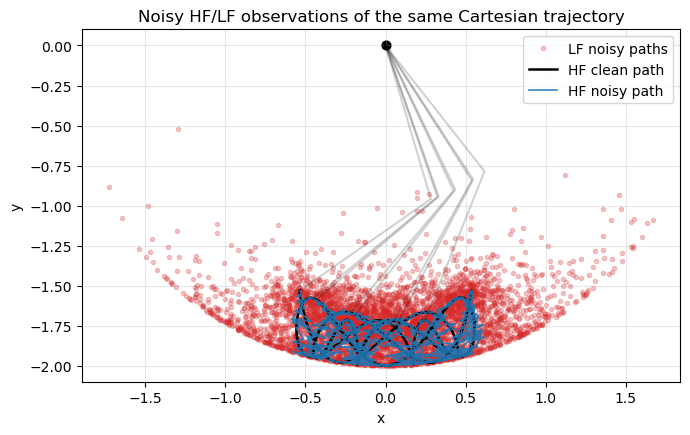

In [2]:
x1 = np.sin(theta1)
y1 = -np.cos(theta1)
x2 = x1 + np.sin(theta2)
y2 = y1 - np.cos(theta2)

hf_x1 = np.sin(hf_theta1)
hf_y1 = -np.cos(hf_theta1)
hf_x2 = hf_x1 + np.sin(hf_theta2)
hf_y2 = hf_y1 - np.cos(hf_theta2)

fig, ax = plt.subplots(figsize=(7, 7))

for idx, lf_traj in enumerate(lf_noisy):
    lf_x1 = np.sin(lf_traj[:, 0])
    lf_y1 = -np.cos(lf_traj[:, 0])
    lf_x2 = lf_x1 + np.sin(lf_traj[:, 2])
    lf_y2 = lf_y1 - np.cos(lf_traj[:, 2])
    label = "LF noisy paths" if idx == 0 else None
    ax.plot(lf_x2, lf_y2, '.', color="#d62728", lw=1.0, alpha=0.25, label=label)

ax.plot(x2, y2, color="black", lw=1.8, label="HF clean path")
ax.plot(hf_x2, hf_y2, color="#1f77b4", lw=1.2, alpha=0.9, label="HF noisy path")

snapshot_idx = np.linspace(0, len(t) - 1, 8, dtype=int)
for idx in snapshot_idx:
    ax.plot([0, x1[idx], x2[idx]], [0, y1[idx], y2[idx]], color="black", alpha=0.18)

ax.scatter([0], [0], color="black", s=40)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Noisy HF/LF observations of the same Cartesian trajectory")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()


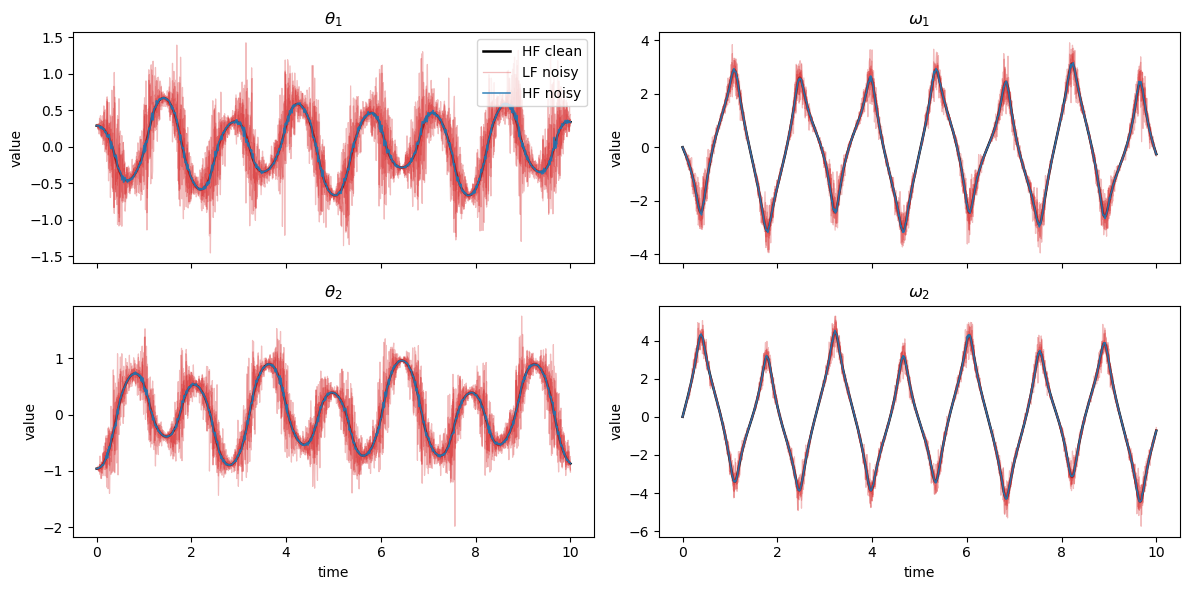

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
state_labels = [r"$\theta_1$", r"$\omega_1$", r"$\theta_2$", r"$\omega_2$"]

for idx, ax in enumerate(axes.ravel()):
    ax.plot(t, hf_clean[:, idx], color="black", lw=1.8, label="HF clean")
    for lf_idx in range(lf_noisy.shape[0]):
        label = "LF noisy" if idx == 0 and lf_idx == 0 else None
        ax.plot(t, lf_noisy[lf_idx, :, idx], color="#d62728", lw=0.9, alpha=0.3, label=label)
    ax.plot(t, hf_noisy[:, idx], color="#1f77b4", lw=1.1, alpha=0.9, label="HF noisy")
    ax.set_title(state_labels[idx])
    ax.set_ylabel("value")

axes[1, 0].set_xlabel("time")
axes[1, 1].set_xlabel("time")
axes[0, 0].legend(loc="upper right")
plt.tight_layout()


## Weighted Weak-SINDy Fit

All three models below use the same weighted weak library with a standard polynomial basis of degree $3$. The only difference is the observation pool that is stacked before the ensemble optimizer is applied:

- `HF`: the single high-fidelity observation,
- `LF`: the five low-fidelity observations,
- `MF`: the full set of one HF plus five LF observations.

In every case, the spatiotemporal weights are the corresponding variance profiles $\sigma(t)^2$, and no additional sample-weight correction is introduced.

In [4]:
fit_results = fit_double_pendulum_hf_lf_models(
    dataset,
    library_kind=LIBRARY_KIND,
    poly_degree=DEFAULT_POLY_DEGREE,
    stlsq_threshold=0.5,
    stlsq_alpha=1e-12,
    n_ensemble_models=25,
    weak_seed=seed,
    n_weak_cells=200,
    weak_window_length=0.05
)

model_titles = {
    "HF": "HF weighted weak-SINDy model",
    "LF": "LF weighted weak-SINDy model",
    "MF": "MF fidelity-weighted weak-SINDy model",
}

for model_name, result in fit_results.items():
    print(model_titles[model_name])
    print(f"number of retained features: {np.count_nonzero(np.abs(result.coefficients) > 1e-12)}")
    for equation in format_weighted_weak_equations(result.coefficients, result.feature_names):
        print(equation)
    print()


/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


HF weighted weak-SINDy model
number of retained features: 31
theta1_dot = -0.503 theta1 + 0.987 omega1 + 1.051 theta1 theta2^2 + 0.842 theta2^3
omega1_dot = -11.618 theta1 - 12.696 theta2 + 31.693 theta1^3 + 105.158 theta1^2 theta2 + 3.411 theta1 omega1^2 + 7.807 theta1 omega1 omega2 + 54.340 theta1 theta2^2 + 1.662 theta1 omega2^2 + 5.741 omega1^2 theta2 + 5.302 omega1 theta2 omega2 + 21.516 theta2^3 + 3.515 theta2 omega2^2
theta2_dot = 0.959 omega2
omega2_dot = -1.541 theta1 + 6.820 theta2 - 1.687 theta1^2 - 3.155 theta1 theta2 - 1.171 theta2^2 - 1.346 theta1^3 - 71.400 theta1^2 theta2 + 0.761 theta1 omega1^2 - 3.996 theta1 omega1 omega2 - 8.828 theta1 theta2^2 - 5.303 omega1^2 theta2 - 2.751 omega1 theta2 omega2 - 15.029 theta2^3 - 2.488 theta2 omega2^2

LF weighted weak-SINDy model
number of retained features: 57
theta1_dot = 1.816 theta1 + 2.169 omega1 + 1.190 theta2 - 0.853 theta1 theta2 - 1.750 theta1^3 - 2.994 theta1^2 omega1 + 0.841 theta1 omega1^2 - 3.204 theta1 omega1 theta2

In [5]:
forecast_horizon = 5
forecast_dt = t[1] - t[0]

# Use the clean terminal training state to isolate model uncertainty.
y0_forecast = hf_clean[-1]
t_future, true_future = simulate_double_pendulum_trajectory(
    y0=y0_forecast,
    t_final=forecast_horizon,
    dt=forecast_dt,
    m1=dataset.m1,
    m2=dataset.m2,
    l1=dataset.l1,
    l2=dataset.l2,
    g=dataset.g,
)
t_future_abs = t[-1] + t_future

state_labels = [r"$\theta_1$", r"$\omega_1$", r"$\theta_2$", r"$\omega_2$"]
model_colors = {
    "HF": "#1f77b4",
    "LF": "#d62728",
    "MF": "#2ca02c"
}
uncertainty_summary = {}
forecast_summaries = {}




100%|██████████| 3/3 [02:44<00:00, 54.97s/it]


Mean 10-90% forecast band width across all states and forecast times:
MF: 0.6622
LF: 1.4688
HF: 2.2421


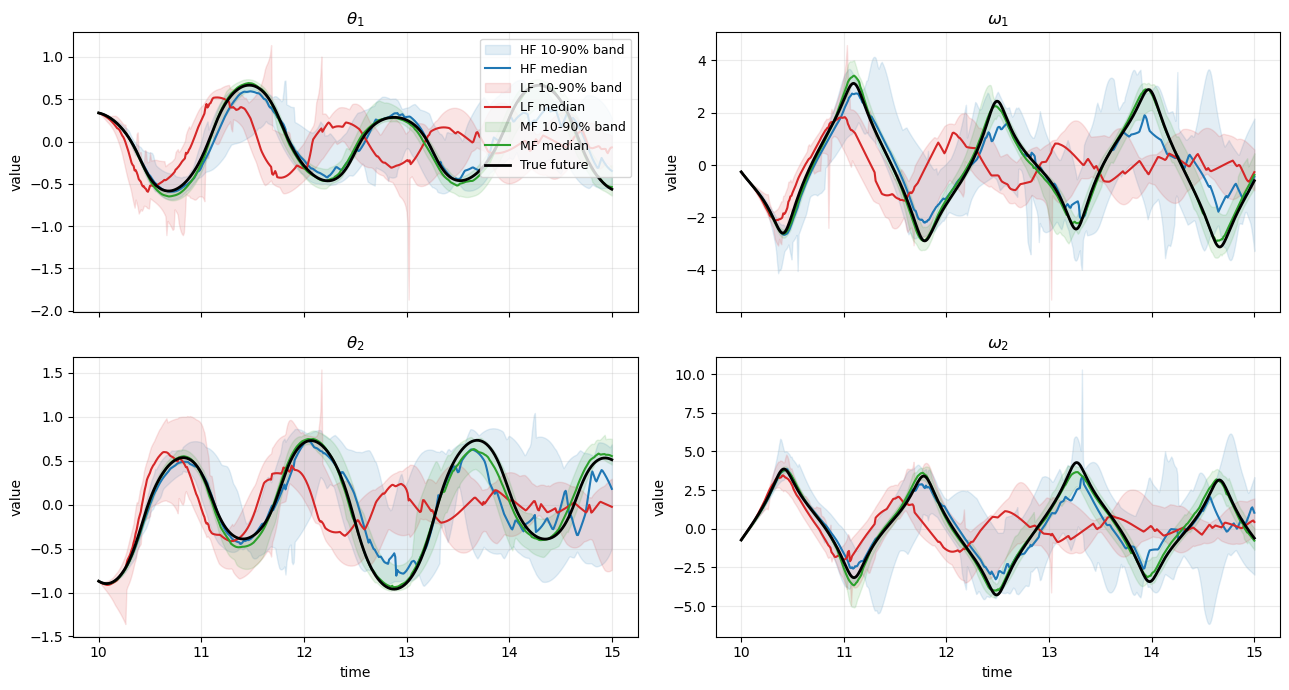

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

for model_name, result in tqdm.tqdm(fit_results.items()):
    # print(result.ensemble_coefficients)
    t_model, ensemble_forecast = simulate_ensemble_sindy_forecast(
        result.ensemble_coefficients,
        y0_forecast,
        library_kind=LIBRARY_KIND,
        poly_degree=DEFAULT_POLY_DEGREE,
        m1=dataset.m1,
        m2=dataset.m2,
        l1=dataset.l1,
        t_final=forecast_horizon,
        dt=forecast_dt,
    )
    median_forecast, lower_forecast, upper_forecast = summarize_ensemble_forecast(
        ensemble_forecast,
        quantile_band=(0.1, 0.9),
    )
    uncertainty_summary[model_name] = float(np.nanmean(upper_forecast - lower_forecast))
    forecast_summaries[model_name] = {
        "median": median_forecast,
        "lower": lower_forecast,
        "upper": upper_forecast,
    }

    for idx, ax in enumerate(axes.ravel()):
        ax.fill_between(
            t_future_abs,
            lower_forecast[:, idx],
            upper_forecast[:, idx],
            color=model_colors[model_name],
            alpha=0.12,
            label=f"{model_name} 10-90% band" if idx == 0 else None,
        )
        ax.plot(
            t_future_abs,
            median_forecast[:, idx],
            color=model_colors[model_name],
            lw=1.5,
            label=f"{model_name} median" if idx == 0 else None,
        )

for idx, ax in enumerate(axes.ravel()):
    ax.plot(t_future_abs, true_future[:, idx], color="black", lw=2.0, label="True future" if idx == 0 else None)
    ax.set_title(state_labels[idx])
    ax.set_ylabel("value")
    ax.grid(True, alpha=0.25)

axes[1, 0].set_xlabel("time")
axes[1, 1].set_xlabel("time")
axes[0, 0].legend(loc="upper right", fontsize=9)
plt.tight_layout()

print("Mean 10-90% forecast band width across all states and forecast times:")
for model_name, width in sorted(uncertainty_summary.items(), key=lambda item: item[1]):
    print(f"{model_name}: {width:.4f}")


Mean 10-90% derivative band width across all states and future times:
MF: 0.3653
HF: 0.6614
LF: 1.7848


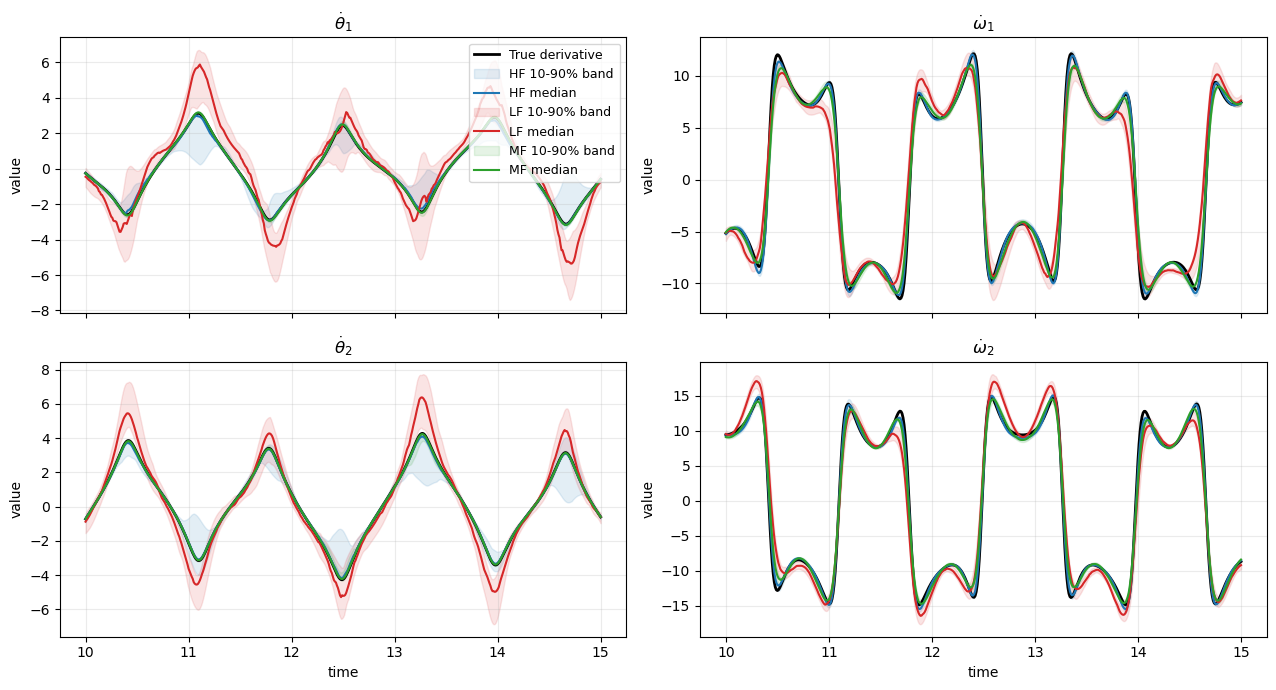

In [7]:
true_future_derivatives = compute_double_pendulum_derivatives(
    true_future,
    m1=dataset.m1,
    m2=dataset.m2,
    l1=dataset.l1,
    l2=dataset.l2,
    g=dataset.g,
)

derivative_labels = [
    r"$\dot{\theta}_1$",
    r"$\dot{\omega}_1$",
    r"$\dot{\theta}_2$",
    r"$\dot{\omega}_2$",
]
derivative_uncertainty_summary = {}
derivative_summaries = {}

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for idx, ax in enumerate(axes.ravel()):
    ax.plot(
        t_future_abs,
        true_future_derivatives[:, idx],
        color="black",
        lw=2.0,
        label="True derivative" if idx == 0 else None,
    )
    ax.set_title(derivative_labels[idx])
    ax.set_ylabel("value")
    ax.grid(True, alpha=0.25)
for model_name, result in fit_results.items():
    ensemble_derivatives = evaluate_ensemble_sindy_derivatives(
        true_future,
        result.ensemble_coefficients,
        library_kind=LIBRARY_KIND,
        poly_degree=DEFAULT_POLY_DEGREE,
        m1=dataset.m1,
        m2=dataset.m2,
        l1=dataset.l1,
    )
    median_derivatives, lower_derivatives, upper_derivatives = summarize_ensemble_forecast(
        ensemble_derivatives,
        quantile_band=(0.1, 0.9),
    )
    derivative_uncertainty_summary[model_name] = float(
        np.nanmean(upper_derivatives - lower_derivatives)
    )
    derivative_summaries[model_name] = {
        "median": median_derivatives,
        "lower": lower_derivatives,
        "upper": upper_derivatives,
    }

    for idx, ax in enumerate(axes.ravel()):
        ax.fill_between(
            t_future_abs,
            lower_derivatives[:, idx],
            upper_derivatives[:, idx],
            color=model_colors[model_name],
            alpha=0.12,
            label=f"{model_name} 10-90% band" if idx == 0 else None,
        )
        ax.plot(
            t_future_abs,
            median_derivatives[:, idx],
            color=model_colors[model_name],
            lw=1.5,
            label=f"{model_name} median" if idx == 0 else None,
        )



axes[1, 0].set_xlabel("time")
axes[1, 1].set_xlabel("time")
axes[0, 0].legend(loc="upper right", fontsize=9)
plt.tight_layout()

print("Mean 10-90% derivative band width across all states and future times:")
for model_name, width in sorted(
    derivative_uncertainty_summary.items(),
    key=lambda item: item[1],
):
    print(f"{model_name}: {width:.4f}")


In [8]:
metric_rows = []

for model_name in fit_results:
    forecast_summary = forecast_summaries[model_name]
    derivative_summary = derivative_summaries[model_name]

    forecast_median = forecast_summary["median"]
    forecast_lower = forecast_summary["lower"]
    forecast_upper = forecast_summary["upper"]
    forecast_valid = (
        np.isfinite(forecast_median)
        & np.isfinite(forecast_lower)
        & np.isfinite(forecast_upper)
        & np.isfinite(true_future)
    )
    forecast_rmse = float(
        np.sqrt(np.mean((forecast_median[forecast_valid] - true_future[forecast_valid]) ** 2))
    )
    forecast_width = float(np.nanmean(forecast_upper - forecast_lower))
    forecast_coverage = float(
        np.mean(
            (true_future[forecast_valid] >= forecast_lower[forecast_valid])
            & (true_future[forecast_valid] <= forecast_upper[forecast_valid])
        )
    )

    derivative_median = derivative_summary["median"]
    derivative_lower = derivative_summary["lower"]
    derivative_upper = derivative_summary["upper"]
    derivative_valid = (
        np.isfinite(derivative_median)
        & np.isfinite(derivative_lower)
        & np.isfinite(derivative_upper)
        & np.isfinite(true_future_derivatives)
    )
    derivative_rmse = float(
        np.sqrt(
            np.mean(
                (derivative_median[derivative_valid] - true_future_derivatives[derivative_valid]) ** 2
            )
        )
    )
    derivative_width = float(np.nanmean(derivative_upper - derivative_lower))
    derivative_coverage = float(
        np.mean(
            (true_future_derivatives[derivative_valid] >= derivative_lower[derivative_valid])
            & (true_future_derivatives[derivative_valid] <= derivative_upper[derivative_valid])
        )
    )

    metric_rows.append(
        (
            model_name,
            forecast_rmse,
            forecast_width,
            forecast_coverage,
            derivative_rmse,
            derivative_width,
            derivative_coverage,
        )
    )

print(
    f"{'Model':<6} {'FcRMSE':>10} {'FcWidth':>10} {'FcCover':>10} {'DerRMSE':>10} {'DerWidth':>10} {'DerCover':>10}"
)
for row in sorted(metric_rows, key=lambda item: item[1]):
    print(
        f"{row[0]:<6} {row[1]:10.4f} {row[2]:10.4f} {row[3]:10.4f} {row[4]:10.4f} {row[5]:10.4f} {row[6]:10.4f}"
    )


Model      FcRMSE    FcWidth    FcCover    DerRMSE   DerWidth   DerCover
MF         0.1440     0.6622     0.9047     0.6651     0.3653     0.6522
HF         0.5206     2.2421     0.9416     0.3099     0.6614     0.7465
LF         1.3495     1.4688     0.5494     1.4957     1.7848     0.5225
